<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/N_Bayes_ForDecision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarea: Modelo de clasificación de sentimiento con NAIVE BAYES.

Fecha: 19/5/2026
Juan Diego Ancarani


**Narrativa:** Un analista decide averiguar sobre clasificación de sentimientos teniendo en cuenta 17 opiniones públicas sobre un videojuego lanzado hace poco.

In [18]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer  #Vectorización (voc. destacado)
from sklearn.naive_bayes import MultinomialNB  #Naive Bayes
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [32]:
#1. Escenario → diferentes videojugadores dejaron su reseña sobre un videojuego.

reseñas = [

           #Reseñas positivas (clase 1)
           'Excelente videojuego, me encantaron los graficos',
           'No puedo esperar ver la secuela',
           'El final me hizo ponerme sentimental, creo que cambio mi vida',
           'Ojala empiecen a sacar videojuegos como este',
           'Excelente acierto de los desarrolladores',
           'Me muero por volverlo a jugar',
           'Deberian darle un premio de oro',

           #Reseñas negativas (Clase 0)
           'No logro alcanzar mis espectativas',
           'Desepcionante, no se que pensaron los desarrolladores',
           'Prefiero mirar el techo, antes de jugar esto',
           'Una desepeción total, si quieren un buen fin de semana no toquen esto',
           'Aburrido de principio a fin',
           'Desperdicie mi dinero comprando este juego',
           'Una pena que hayan desperdiciado tal potencial'

]

etiquetas = [1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0] #Analisis de sentimientos.

#Probabilidad de buena reseña = 1/2
#Probabilidad de mala reseña = 1/2

In [33]:
#2. Vectorización

vectorizador = CountVectorizer(stop_words = None)
X = vectorizador.fit_transform(reseñas)

print('--'*60)
print('Naive Bayes- Clasificador de sentimientos')
print('--'*60)
print(f"\nVocabulario detectado: {vectorizador.get_feature_names_out()}")
print(f"Forma de la matriz: {X.shape} (reseñas × palabras únicas)")

------------------------------------------------------------------------------------------------------------------------
Naive Bayes- Clasificador de sentimientos
------------------------------------------------------------------------------------------------------------------------

Vocabulario detectado: ['aburrido' 'acierto' 'alcanzar' 'antes' 'buen' 'cambio' 'como'
 'comprando' 'creo' 'darle' 'de' 'deberian' 'desarrolladores'
 'desepcionante' 'desepeción' 'desperdiciado' 'desperdicie' 'dinero' 'el'
 'empiecen' 'encantaron' 'espectativas' 'esperar' 'este' 'esto'
 'excelente' 'fin' 'final' 'graficos' 'hayan' 'hizo' 'juego' 'jugar' 'la'
 'logro' 'los' 'me' 'mi' 'mirar' 'mis' 'muero' 'no' 'ojala' 'oro' 'pena'
 'pensaron' 'ponerme' 'por' 'potencial' 'prefiero' 'premio' 'principio'
 'puedo' 'que' 'quieren' 'sacar' 'se' 'secuela' 'semana' 'sentimental'
 'si' 'tal' 'techo' 'toquen' 'total' 'un' 'una' 'ver' 'vida' 'videojuego'
 'videojuegos' 'volverlo']
Forma de la matriz: (14, 72) (reseñas

In [34]:
#3. División de Train/Test.
etiquetas = etiquetas[:X.shape[0]]

X_train, X_test, y_train, y_test = train_test_split(X, etiquetas, test_size = 0.2, random_state = 42)

print(f' Entrenamiento: {X_train.shape[0]} reeñas.') #→ 80% de reseñas x entre.
print(f' Prueba: {X_test.shape[0]} reseñas.') #→ 20% de reseñas x prueb.

 Entrenamiento: 11 reeñas.
 Prueba: 3 reseñas.


--Modelo entrenado--
Accuracy score: 66.67%
--REPORTE DE CLASIFICACIÓN--
              precision    recall  f1-score   support

   Negativas       1.00      0.50      0.67         2
   Positivas       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



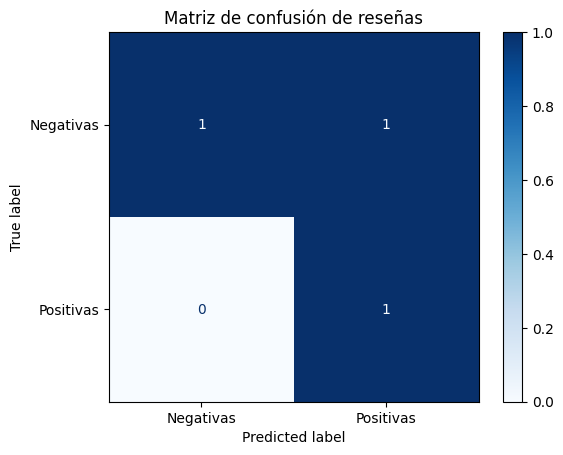

Problema accuracy (0.6666666666666666), pq define positivo, cuando deberia ser negativo


In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#4. Entreamiento del modelo y evaluación.

modelo = MultinomialNB()
modelo.fit(X_train, y_train)

print('=' *60)
print('--Modelo entrenado--')
print('=' *60)

predicciones = modelo.predict(X_test)


print(f'Accuracy score: {accuracy_score(y_test, predicciones):.2%}')
print('--REPORTE DE CLASIFICACIÓN--')
print(classification_report(y_test, predicciones, target_names = ['Negativas', 'Positivas']))


cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Negativas', 'Positivas'])
disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusión de reseñas')
plt.show()

print(f'Problema accuracy ({accuracy_score(y_test, predicciones)}), pq define positivo, cuando deberia ser negativo')

In [36]:
#6. Predicción en las nuevas reseñas
print('=' *60)
print('--PREDICCIONES CON NUEVAS RESEÑAS--')
print('=' *60)

nuevas_reseñas = [

    'Me lo esperaba que sea genial.',
    'Prefiero jugar juegos para bebes.',
    'tenia altas espectativas y termine pasando un mal rato.',
    'Desepcionante elenco de personajes nuevos.',
    'Grandes graficas para la epoca.'
]


X_nuevas = vectorizador.transform(nuevas_reseñas)
predicciones_nuevas = modelo.predict(X_nuevas)
probabilidades = modelo.predict_proba(X_nuevas)

for reseña, pred, prob in zip(nuevas_reseñas, predicciones_nuevas, probabilidades):
  clase = 'Positiva ⭐' if pred == 1 else 'Negativa ❌'
  confianza = max(prob) *100
  print(f' {reseña}')
  print(f' → clase: {clase} - confianza: {confianza:.1f}%)')

  print('--'*60)
  print('--PREDICCIONES CON 66% DE EXACTITUD--')


--PREDICCIONES CON NUEVAS RESEÑAS--
 Me lo esperaba que sea genial.
 → clase: Positiva ⭐ - confianza: 88.4%)
------------------------------------------------------------------------------------------------------------------------
--PREDICCIONES CON 66% DE EXACTITUD--
 Prefiero jugar juegos para bebes.
 → clase: Positiva ⭐ - confianza: 77.2%)
------------------------------------------------------------------------------------------------------------------------
--PREDICCIONES CON 66% DE EXACTITUD--
 tenia altas espectativas y termine pasando un mal rato.
 → clase: Positiva ⭐ - confianza: 77.2%)
------------------------------------------------------------------------------------------------------------------------
--PREDICCIONES CON 66% DE EXACTITUD--
 Desepcionante elenco de personajes nuevos.
 → clase: Positiva ⭐ - confianza: 83.5%)
------------------------------------------------------------------------------------------------------------------------
--PREDICCIONES CON 66% DE EXACTITU

In [37]:
#7. Palabras mas discriminativas por tipo de reseña (pos/neg).

print("\n" + "=" * 60)
print("PALABRAS MÁS INDICATIVAS POR CLASE: ")
print("=" * 60)

feature_names = vectorizador.get_feature_names_out()
log_prob = modelo.feature_log_prob_

#Top 5- palabras positivas.
top_pos =  np.argsort(log_prob[1])[-5:]
print('TOP 5 PALABRAS POSITIVAS: ')
for idx in top_pos:
  print(f'-{feature_names[idx]}')


print('..'*20)
#Top 5- palabras negativas.

top_neg = np.argsort(log_prob[0])[-5:]
print('TOP 5 PALABRAS NEGATIVAS: ')
for idx in top_neg:
  print(f'-{feature_names[idx]}')




PALABRAS MÁS INDICATIVAS POR CLASE: 
TOP 5 PALABRAS POSITIVAS: 
-que
-me
-de
-los
-no
........................................
TOP 5 PALABRAS NEGATIVAS: 
-semana
-que
-total
-un
-una
